In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import Holt

In [16]:
df = pd.read_csv('sales.csv')
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

In [17]:
df.head()

,sales
date,
2022-01-01,1200
2022-01-02,980
2022-01-03,1100
2022-01-04,870
2022-01-05,760


In [18]:
train = df.iloc[:-14]
test  = df.iloc[-14:]
h = len(test)

In [19]:
# Manual Holt
def manual_holt(alpha, beta, data):
    data = data.values  # Converts pandas series into numpy array
    L = [data[0]]       # Initial Level --> L[1] = y(1)
    T = [data[1] - data[0]]     # InitialTrend
    # initialises the fitted (in-sample forecast) list. The fitted value at t=1 is just the initial level — there is nothing to forecast before the series starts.
    fitted = [data[0]]

    # We are looping from 1 to the end. We are computing L(2)...
    for i in range(1, len(data)):
        # Storing the previous level and trend
        L_prev = L[i-1]
        T_prev = T[i-1]

        # Level Update equation
        L_new = alpha * data[i] + (1-alpha)*(L_prev + T_prev)
        # Trend update equation
        T_new = beta * (L_new - L_prev) + (1-beta)*T_prev

        L.append(L_new)
        T.append(T_new)

        # the in-sample fitted value at this step. The one-step-ahead forecast made at the previous step was L(t-1) + T(t-1). Storing these fitted values allows you to plot how well the model tracked the training data
        fitted.append(L_prev + T_prev)
    return np.array(L), np.array(T), np.array(fitted)

In [20]:
alpha, beta = 0.4, 0.3
L, T, fitted = manual_holt(alpha, beta, train['sales'])

In [21]:
# Forecast — last level + h steps of last trend
fc_manual = pd.Series(
    [L[-1] + (i + 1) * T[-1] for i in range(h)],
    index=test.index
)

In [22]:
#  statsmodels Holt (optimised α and β)

# Creating the Holt model object
model  = Holt(train['sales'], initialization_method='estimated')

# model_add.fit(optimized=True) — fits the model. The optimiser simultaneously finds the best α, β, L(1), and T(1) that minimise in-sample SSE. Returns a fitted model object.
fitted_model = model.fit(optimized=True)
# generates 14 future forecasts. Returns a pandas Series with the correct future date index already set.
fc_stats     = fitted_model.forecast(h)

# extracts the optimal α
opt_alpha = fitted_model.params['smoothing_level']
# extracts the optimal β
opt_beta  = fitted_model.params['smoothing_trend']

print(f"Manual  α={alpha}, β={beta}            MAE: {np.mean(np.abs(fc_manual - test['sales'])):.2f}")
print(f"Optimal α={opt_alpha:.3f}, β={opt_beta:.3f}   MAE: {np.mean(np.abs(fc_stats  - test['sales'])):.2f}")
print(f"\nFinal level : {L[-1]:.2f}")
print(f"Final trend : {T[-1]:.2f}  (forecast increases by this per step)")



Manual  α=0.4, β=0.3            MAE: 1088.79
Optimal α=0.015, β=0.015   MAE: 411.38

Final level : 3402.81
Final trend : 129.18  (forecast increases by this per step)


D:\Complete ML\FastAPI\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


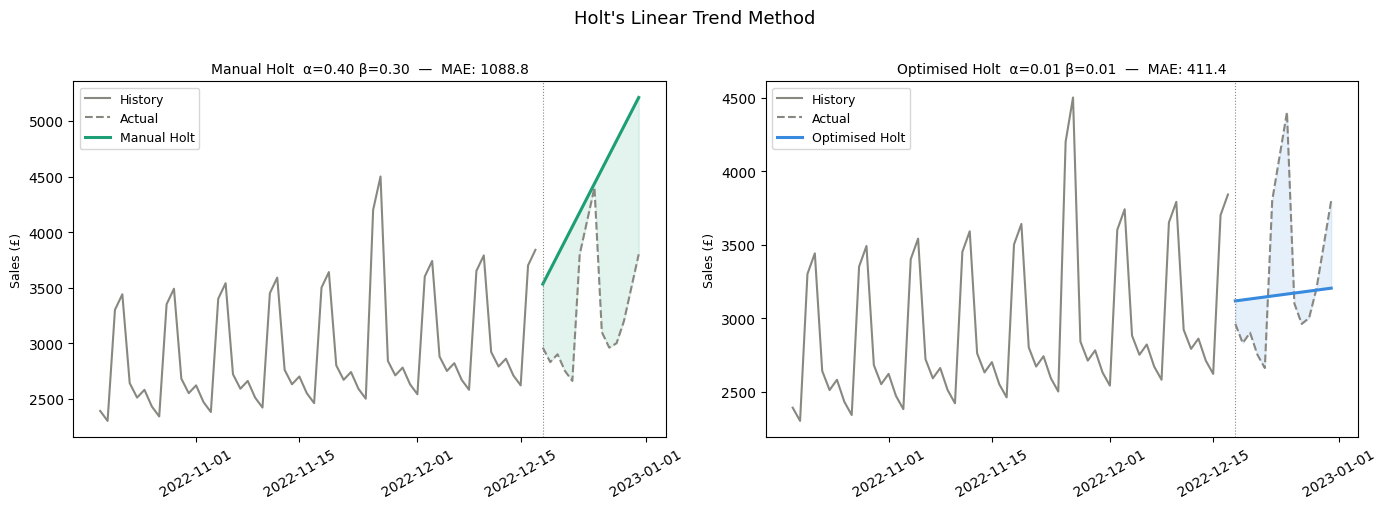

In [23]:
# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
train_plot = train['sales'].iloc[-60:]

for ax, (fc, label, a_val, b_val, color) in zip(axes, [
    (fc_manual, 'Manual Holt',    alpha,     beta,     '#1D9E75'),
    (fc_stats,  'Optimised Holt', opt_alpha, opt_beta, '#378ADD'),
]):
    ax.plot(train_plot.index, train_plot.values,
            color='#888780', linewidth=1.5, label='History')
    ax.plot(test.index, test['sales'].values,
            color='#888780', linewidth=1.5, linestyle='--', label='Actual')
    ax.plot(test.index, fc.values,
            color=color, linewidth=2.2, label=label)
    ax.fill_between(test.index, fc.values, test['sales'].values,
                    alpha=0.12, color=color)
    ax.axvline(test.index[0], color='#888780', linewidth=0.8, linestyle=':')
    mae_val = np.mean(np.abs(fc - test['sales']))
    ax.set_title(f'{label}  α={a_val:.2f} β={b_val:.2f}  —  MAE: {mae_val:.1f}',
                 fontsize=10)
    ax.legend(fontsize=9)
    ax.tick_params(axis='x', rotation=30)
    ax.set_ylabel('Sales (£)', fontsize=9)

plt.suptitle("Holt's Linear Trend Method", fontsize=13, fontweight='500', y=1.01)
plt.tight_layout()
plt.savefig('holts_method.png', dpi=150, bbox_inches='tight')
plt.show()